### Step 1 Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Step 2 Load Dataset

In [2]:
df = pd.read_csv('../data/SampleSuperstore.csv')

Displaying 1st 5 rows

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


Displaying last 5 rows

### Step 3 Initial Exploration

#### Dataset Shape

In [4]:
df.shape

(9994, 13)

#### Column Names

In [5]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

#### Data Types

In [6]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

#### Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


#### Summary Statistics

In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Average Sales?

In [9]:
df['Sales'].mean()

np.float64(229.85800083049827)

Max Profit?

In [10]:
df['Profit'].max()

8399.976

Min discounts?

In [11]:
df['Discount'].min()

0.0

### Step 4 Data Cleaning

#### Missing Values

In [12]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

**Visualize percentage**

In [13]:
missing = df.isnull().sum()
missing = missing[missing>0]
missing

Series([], dtype: int64)

if small

In [14]:
df.dropna(inplace=True)

if numeric

In [15]:
df["Sales"].fillna(df["Sales"].mean())

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9989     25.2480
9990     91.9600
9991    258.5760
9992     29.6000
9993    243.1600
Name: Sales, Length: 9994, dtype: float64

#### Duplicate Values

In [16]:
df.duplicated().sum()

np.int64(17)

Remove Duplicates

In [17]:
df.drop_duplicates(inplace=True)

#### Fix Data Types

In [18]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [19]:
df['Postal Code'] = df['Postal Code'].astype(str)

In [20]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code      object
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

#### Remane Columns

In [21]:
df.columns = df.columns.str.replace(" ","_")

In [22]:
df.columns

Index(['Ship_Mode', 'Segment', 'Country', 'City', 'State', 'Postal_Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

#### Remove Extra Spaces

In [23]:
df["City"] = df["City"].str.strip()

#### Standardize Text

In [24]:
df['Region'] = df['Region'].str.title()

In [25]:
df.head(10)

,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700


#### Check Unique Values

In [26]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

#### Feature Engineering

##### Profit Margin

In [27]:
profit_margin = (
    df.groupby("Category")["Profit"].sum() /
    df.groupby("Category")["Sales"].sum()
) * 100
df["Profit_Margin"] = df["Category"].map(profit_margin)
df["Profit_Margin"] = df["Profit_Margin"].astype(int).astype(str) + '%'

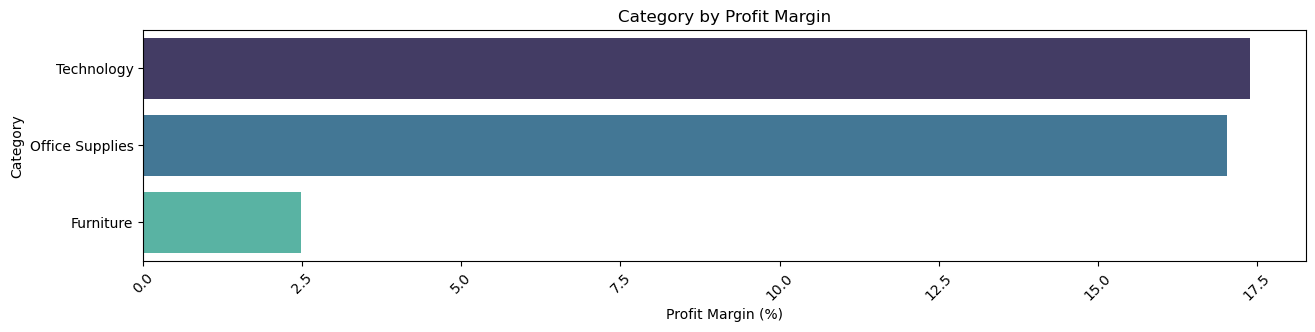

In [50]:
top10 = (
    df.groupby('Category')[['Sales', 'Profit']]
    .sum()
    .assign(Profit_Margin=lambda x: (x['Profit'] / x['Sales']) * 100)
    .sort_values('Profit_Margin', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(15,3))
sns.barplot(data=top10, y='Category', x='Profit_Margin', palette='mako')
plt.xticks(rotation=45)
plt.ylabel('Category')
plt.xlabel('Profit Margin (%)')
plt.title('Category by Profit Margin')
plt.savefig("../images/profitMargin.jpeg")
plt.show()


### Step 5 — Exploratory Data Analysis

#### Total Sales

In [29]:
df['Sales'].sum()

np.float64(2296195.5903)

#### Total Profit

In [30]:
df['Profit'].sum()

np.float64(286241.42260000005)

#### Total Sales

In [31]:
df['Quantity'].sum()

np.int64(37820)

#### Top Categories

In [32]:
topCategories = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
topCategories

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64

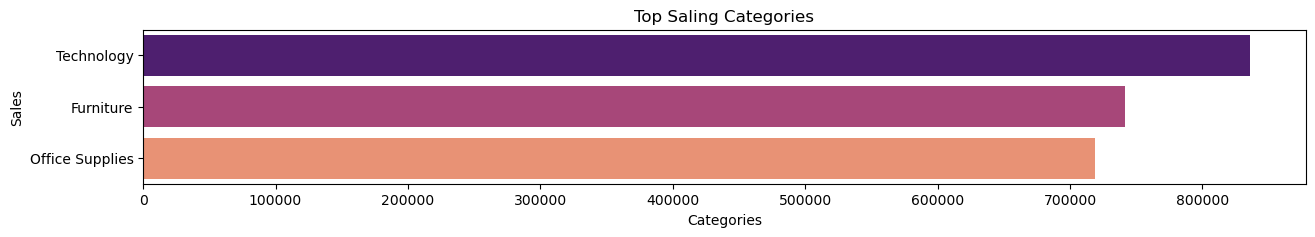

In [51]:
plt.figure(figsize=(15,2))
sns.barplot(y=topCategories.index, x=topCategories.values, palette='magma')
plt.xlabel('Categories')
plt.ylabel('Sales')
plt.title("Top Saling Categories")
plt.savefig("../images/topSellingCategories.jpeg")


#### Sales by Region

In [34]:
regionalSales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

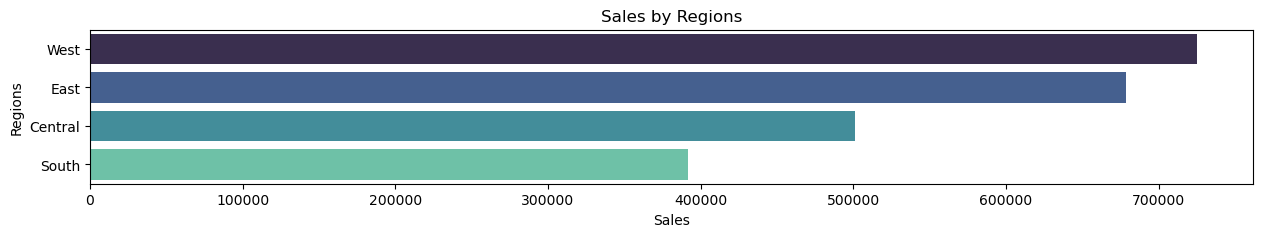

In [52]:
plt.figure(figsize=(15,2))
sns.barplot(y=regionalSales.index, x=regionalSales.values, palette='mako')
plt.xlabel('Sales')
plt.ylabel('Regions')
plt.title('Sales by Regions')
plt.savefig("../images/salesByRegions.jpeg")


#### Top 10 Products

In [36]:
topProducts = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
topProducts

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

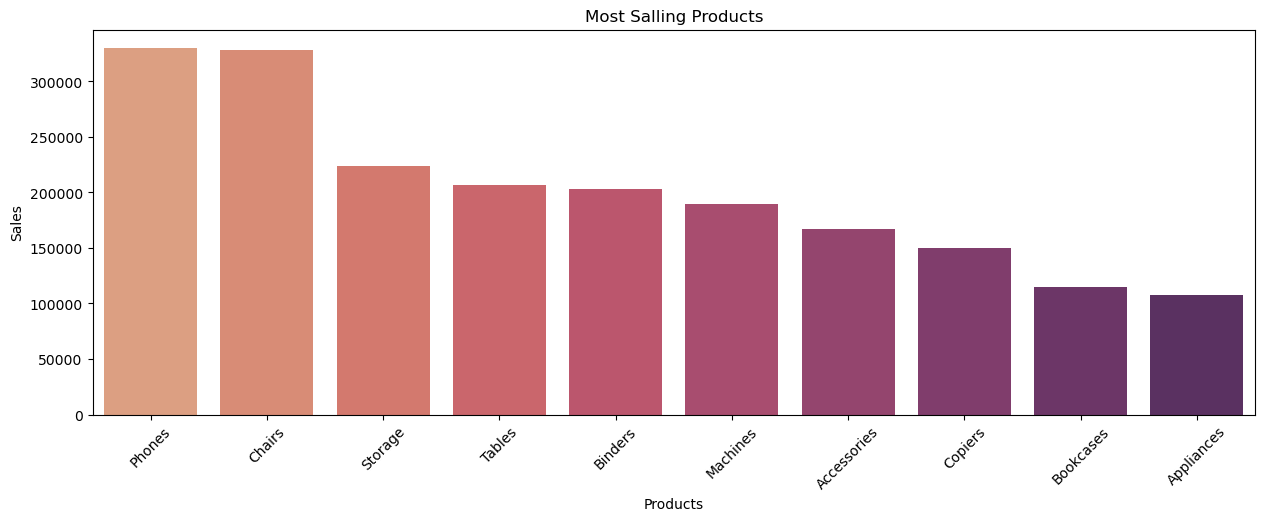

In [53]:
plt.figure(figsize=(15,5))
sns.barplot(x=topProducts.index, y= topProducts.values, palette='flare')
plt.xlabel('Products')
plt.ylabel("Sales")
plt.title('Most Salling Products')
plt.xticks(rotation=45)
plt.savefig("../images/mostSellingProducts.jpeg")



#### Shipping Mode

In [38]:
ship = df.groupby("Ship_Mode")["Sales"].sum().sort_values(ascending=False)
ship

Ship_Mode
Standard Class    1.357316e+06
Second Class      4.591770e+05
First Class       3.513805e+05
Same Day          1.283217e+05
Name: Sales, dtype: float64

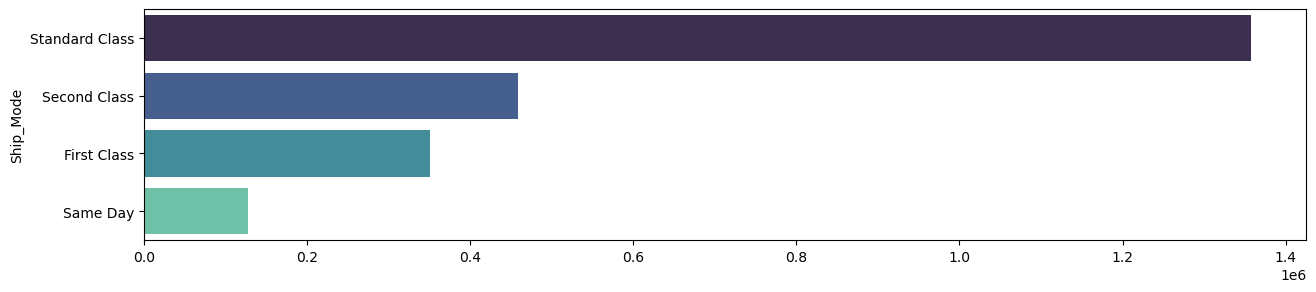

In [54]:
plt.figure(figsize=(15,3))
sns.barplot(x=ship.values, y=ship.index, palette='mako')
plt.savefig("../images/shippingMode.jpeg")


#### Discount Analysis

In [40]:
discountAnalysis = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False).head(10)
discountAnalysis

Sub-Category
Binders        0.372011
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170244
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138494
Fasteners      0.082028
Name: Discount, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Binders'),
  Text(1, 0, 'Machines'),
  Text(2, 0, 'Tables'),
  Text(3, 0, 'Bookcases'),
  Text(4, 0, 'Chairs'),
  Text(5, 0, 'Appliances'),
  Text(6, 0, 'Copiers'),
  Text(7, 0, 'Phones'),
  Text(8, 0, 'Furnishings'),
  Text(9, 0, 'Fasteners')])

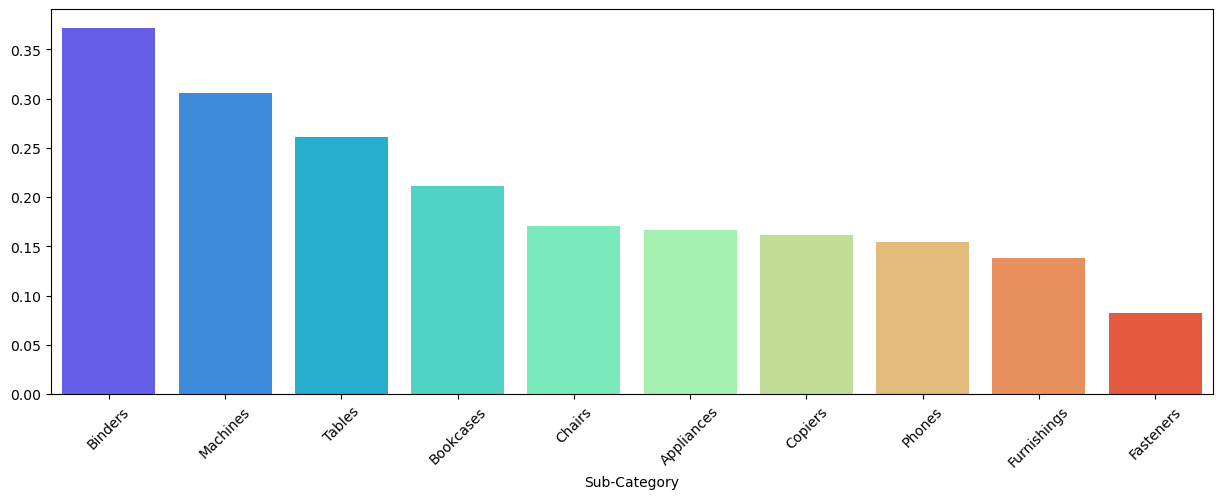

In [41]:
plt.figure(figsize=(15,5))
sns.barplot(x=discountAnalysis.index, y=discountAnalysis.values, palette='rainbow')
plt.xticks(rotation=45)

### Step 6 — Business Questions

Which region has highest sales?

In [42]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(1)

Region
West    725255.6365
Name: Sales, dtype: float64

Which category earns highest profit?

In [43]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False).head(1)

Category
Technology    145454.9481
Name: Profit, dtype: float64

Which state loses money?

In [44]:
df.groupby("State")["Profit"].sum().sort_values().head(10)

State
Texas            -25750.9833
Ohio             -16959.3178
Pennsylvania     -15565.4035
Illinois         -12601.6500
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1194.0993
Name: Profit, dtype: float64

Does discount reduce profit?

In [45]:
df.groupby("Discount")["Profit"].mean().sort_values().head(10)

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -102.116395
0.70    -95.874060
0.32    -88.560656
0.30    -45.828401
0.60    -43.077212
0.20     24.721217
0.15     27.288298
Name: Profit, dtype: float64

### Step 7 Key Insights

The **West** region generated the highest revenue.

**Technology** had the highest total profit.

The biggest revenue-driving sub-categories are **Phones** (330,007.05) and **Chairs** (327,777.76).

Highest discount is given on **Binders**.

**Standard Class** is the most shipping mode.

### Step 8 Export Cleaned Dataset

In [46]:
df.to_csv("../cleaned_data/Superstore_Cleaned.csv")